# The chain problem
The 5-state Chain problem [Strens,2000], requires the MDP agent to select between
two abstract actions {1, 2}. Action 1 causes the agent to move to the
right with probability 0.8 and causes the agent to reset to the initial state with probability 0.2. Action 2 causes the agent to reset with probability 0.8 and causes the agent to move to the right with probability 0.2. The action b has constant reward of +2. Rewards vary based on the state and effect (“a” and “b”).
The optimal policy is to always choose action 1, causing the agent to potentially receive +10 several times until slipping back (randomly) to the initial state. Of course if the transition probabilities and rewards are not known, the agent has to trade-off exploration and exploitation to learn this optimal policy.

In this notebook we will show how traditional RL algorithms such as **MC** and **SARSA** can be outperformed by a Bayesian Inference approach, that is **Posterior Sampling**.

### References
[1] Strens, 2000, A Bayesian Framework for Reinforcement Learning, https://dl.acm.org/doi/10.5555/645529.658114


[2] Ghavamzadeh et al., 2016, Bayesian Reinforcement Learning: A Survey, https://arxiv.org/abs/1609.04436

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

dir_name = 'chain'
os.makedirs(dir_name, exist_ok = True)

## 1. Dynamic Programming solution
First off we define some useful functions for the notebook and implement the **Dynamic Programming** solution. Dynamic Programming is considered to be the "analytic solution" for a known MDP: we assume here to completely know the dynamics of the problem and achieve:
- an estimate of $Q(s,a)$ (state-action value) for all pairs
- an estimate of $\pi$ (policy) that is the action that maximizes the expected return given the state

The results provided by DP are accurate up to a small accuracy threshold

In [2]:
def plot_chain(V, pi, gradient, actions):
    if gradient:
        display_grid = V
        cmap = 'viridis'
        vmin = np.min(V)
        vmax = np.max(V)
    else:
        cmap = 'gray'
        vmin = 0
        vmax = 1
        display_grid = np.ones_like(V)

    rows, cols = V.shape
    if actions:
        fig, ax = plt.subplots(figsize=(cols * 1.2, rows * 1.2))
    else:
        fig, ax = plt.subplots(figsize=(cols * 1.1, rows * 1.1))

    ax.imshow(display_grid, cmap=cmap, vmin=vmin, vmax=vmax, alpha=1)
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color='black', linewidth=1.5)
    ax.tick_params(which='minor', size=0)
    if actions:
        arrow_scale = 0.3
        head_size = 0.15
        for i in range(rows):
            for j in range(cols):
                dx, dy = 0, 0
                if pi[j] == 0:    # right
                    dx = arrow_scale
                elif pi[j] == 1:  # reset
                    dx = -arrow_scale
                ax.arrow(
                    j - dx * 0.5,
                    i - dy * 0.5,
                    dx,
                    dy,
                    head_width=head_size,
                    head_length=head_size,
                    fc='black',
                    ec='black',
                    linewidth=1.5,
                    length_includes_head=True,
                    zorder=2
                )
    else:
        for i in range(rows):
            for j in range(cols):
                ax.text(j, i, str(round(V[i, j], 3)),
                        ha='center', va='center',
                        fontsize=int(12. / cols * 5), color='black')
        plt.colorbar(ax.images[0], ax=ax,label='V estimate')

    plt.tight_layout()
    plt.show()

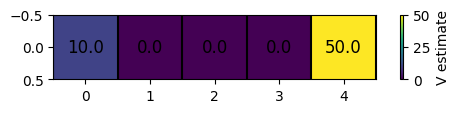

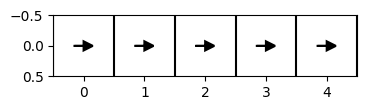

In [3]:
# initialization
chain_length = 5
V = np.zeros(chain_length)
pi = np.random.randint(2,size = chain_length)   # initialize actions randomly as 0 (left) or 1 (right)
gamma = 0.8

####################
# POLICY ITERATION #
#################### 

# policy iteration evaluates the policy on the problem and improves it greedily until convergence
policy_stable = False
while policy_stable == False:
    theta = 0.25   # accuracy thresh
    delta = 0.5
    # Policy evaluation (evaluates current policy)
    while delta > theta:
        delta = 0
        theta = 10.
        # loop across states
        for state in range(chain_length):
            action = pi[state]
            v = V[state]

            if action == 0:  # move right with p=0.8, reset p = 0.2
                rand = np.random.uniform(0,1)
                if rand <= 0.8:
                    state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10  # no reward for moving on right (10 if last state)
                else:
                    state = 0
                    r = 2  # reset leads reward 2
            if action == 1:  # move right with p=0.2, reset p = 0.8
                rand = np.random.uniform(0,1)
                if rand <= 0.2:
                    state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10 # no reward for moving on right (10 if last state)
                else:
                    state = 0
                    r = 2  # reset leads reward 2
            V[state] = r + gamma * V[state]
            delta = max(delta, abs(v-V[state]))
            #print(delta)
            
    # POLICY IMPROVEMENT LOOP
    # policy improvement takes the current policy and evaluates what is the greedy choice on Q
    # if policy and greedy choice match for all states, we have found the best policy
    # if not, improve greedily and evaluate with Policy evaluation
    policy_stable = True
    for state in range(chain_length):
        old_action = pi[state]

        # check all actions
        temp = []
        valid_actions = []
        for action_idx in range(chain_length):
            
            if action_idx == 0:  # move right with p=0.8, reset p = 0.2
                rand = np.random.uniform(0,1)
                if rand <= 0.8:
                    state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10  # no reward for moving on right (10 if last state)
                else:
                    state = 0
                    r = 2  # reset leads reward 2
            if action_idx == 1:  # move right with p=0.2, reset p = 0.8
                rand = np.random.uniform(0,1)
                if rand <= 0.2:
                    state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10 # no reward for moving on right (10 if last state)
                else:
                    state = 0
                    r = 2  # reset leads reward 2
            temp.append(r+gamma * V[state])
            valid_actions.append(action_idx)

            best_action = valid_actions[np.argmax(np.array(temp))]
            pi[state] = best_action
            if best_action != old_action:
                policy_stable = False
    #print(pi)
plot_chain(V.reshape(1,chain_length),pi,gradient = True,actions = False)
plot_chain(V.reshape(1,chain_length),pi,gradient = False,actions = True)

## 1.1: Cumulative Reward estimate over time with best policy
We want to estimate the average reward provided by the policy. Being the problem intrinsically stochastic, we run for a very high number of steps the obtain policy and extract the average Reward (averaged over number of steps).

In [4]:
def policy_estimator(pi,chain_length,max_iter,plot_flag,path,tipo):
    state = 0 # initial state
    rewards = []
    times = []
    
    for t in range(max_iter):
        action = pi[state]
        if action == 0:  # move right with p=0.8, reset p = 0.2
            rand = np.random.uniform(0,1)
            if rand <= 0.8:
                state = min(state + 1,chain_length-1)
                r = 0 if state != chain_length-1 else 10  # no reward for moving on right (10 if last state)
            else:
                state = 0
                r = 2  # reset leads reward 2
        if action == 1:  # move right with p=0.2, reset p = 0.8
            rand = np.random.uniform(0,1)
            if rand <= 0.2:
                state = min(state + 1,chain_length-1)
                r = 0 if state != chain_length-1 else 10 # no reward for moving on right (10 if last state)
            else:
                state = 0
                r = 2  # reset leads reward 2
        rewards.append(r)
        times.append(t)

    cum_r = np.cumsum(rewards)
    if plot_flag:
        plt.plot(times[1:], cum_r[1:] / np.array(times)[1:],label = f'avg reward {tipo}')
        plt.xlabel('time')
        plt.ylabel('mean R')
        plt.grid(alpha = 0.6)
        plt.legend()
        plt.savefig(path)
        plt.show()
    
    return times, rewards, cum_r, cum_r[1:] / np.array(times[1:])

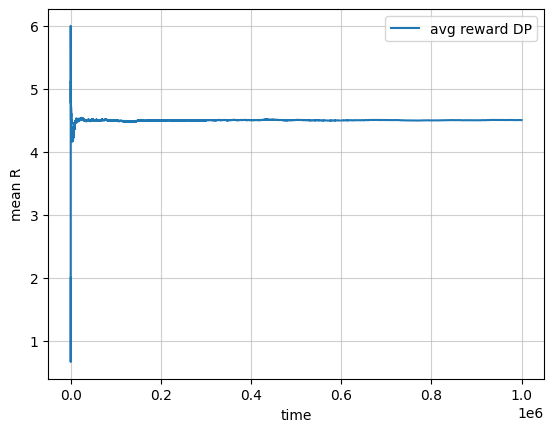

In [5]:
max_iter = int(1e6)
path = dir_name +'/DP_reward.png'
t_DP,r_DP,cum_r_DP,avg_cum_r_DP = policy_estimator(pi,chain_length,max_iter,plot_flag = True,path=path,tipo='DP')

In [6]:
best_R = avg_cum_r_DP[-1]
print(f'best average Reward for unit time is {round(best_R,3)}')

best average Reward for unit time is 4.505


We have that the average reward is ~4.5 per step. We would like our algorithms to achieve such value, up to a small error probability $\epsilon$, that is set to allow exploration. Any algorithm is expected, at convergence, to take the best action with probability $1-\epsilon$, since it was set to being constant (other approaches let it decay with time, but for simplicity we kept at its fixed value).

## 2: Monte Carlo solution (exploring starts)
Monte Carlo is the first and simplest solution we implement. It is a traditional RL algorithm that consists in:
1) Random initialization of policy $\pi$ and state-action values $Q(s,a)$ for all $(s,a)$ pairs
2) Initialization of the episode (initial state) and ensurement that all actions have probability > 0 (ensure exploration)
3) Run a complete episode following $\pi$
4) Compute the returns as $G_t = R_t + G_{t-1}$ for $t = T-1,...,0$ (reversing time saves computational resources)
5) (FIRST VISIT), for all $t$, if $(s_t,a_t)$ not in $[(s_{t-1},a_{t-1}),...,(s_0,a_0))$, append $G$ to returns of $(s_t,a_t)$ and update $Q(s_t,a_t) = <returns(s_t,a_t)>$ (mean of recorded returns)
6) Go back to 2.

Monte Carlo is a simple, yet effective approach on solving RL problems. The main issue with MC lies in its stochastic nature: if $\pi$ is initialized so that it quickly discovers the best strategy, the convergence is fast. Otherwise it may take a long time for MC to discover the best strategy. We perform the MC loop (from 1. to 6.) 100 times (n_runs) to provide an average estimate of its performance

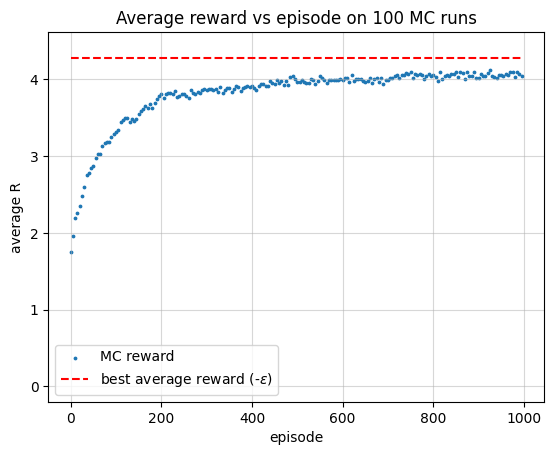

3.809 0.408


In [7]:
# initialization
chain_length = 5
n_runs = 100
total_episodes = int(1e3)
modulo = int(total_episodes / 200)
accuracies = np.zeros(int(total_episodes / modulo))

for n_run in range(n_runs):
    Q = np.zeros((chain_length,2))
    pi = np.random.randint(2,size = chain_length)   # initialize actions randomly as 0 (left) or 1 (right)
    gamma = 0.8
    epsilon = 0.05
    
    max_steps = 25    # 2*chain_length**2
    returns = np.zeros((chain_length,2))  # to store returns
    counters = np.zeros((chain_length,2))  # to count how many stored returns
    
    
    acc = []
    pis = []
    episodes = []
    
    start_time = time.time()
    for episode in range(total_episodes):
        # episode initialization
        state = 0
    
        seen_s = []
        seen_a = []
        rewards = []
    
        # loop with monte carlo across the episode
        for _ in range(max_steps):
            # possibility of random action
            rand = np.random.uniform(0,1)
            if rand<epsilon:
                action_index = np.random.randint(2)
            else:
                action_index = pi[state]
            seen_s.append(state)
            seen_a.append(action_index)
    
            # determine outcome of the action
            if action_index == 0:  # move right with p=0.8, reset p = 0.2
                rand = np.random.uniform(0,1)
                if rand <= 0.8:
                    state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10  # no reward for moving on right (10 if last state)
                else:
                    state = 0
                    r = 2  # reset leads reward 2
            if action_index == 1:  # move right with p=0.2, reset p = 0.8
                rand = np.random.uniform(0,1)
                if rand <= 0.2:
                    state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10 # no reward for moving on right (10 if last state)
                else:
                    state = 0
                    r = 2  # reset leads reward 2
    
            # update state and save r
            rewards.append(r)
        # finished episode, now compute returns
        G = 0
        for t in range(max_steps-1,-1,-1):  # reverse index loop
            G = gamma * G + rewards[t]
            st = seen_s[t-1]
            at = seen_a[t-1]
            if (st,at) not in zip(seen_s[:(t-2)],seen_a[:(t-2)]):
                returns[st,at] += G
                counters[st,at] += 1
                Q[st,at] = returns[st,at]/counters[st,at]
                pi[st] = np.argmax(Q[st,:])
                
        # evaluation logic
        if episode % modulo== 0:
            eval_iter = 1000
            _,_,_,avg_cum = policy_estimator(pi,chain_length,eval_iter,plot_flag=False,path=None,tipo = 'MC')
            acc.append(avg_cum[-1])
            episodes.append(episode)
            pis.append(pi)
    # at the end of the run save the data
    accuracies = np.array(acc) / (n_run + 1) + accuracies * (n_run)/(n_run+1)
    
plt.scatter(episodes,accuracies, label = 'MC reward',s=3)
plt.title(f'Average reward vs episode on {n_runs} MC runs')
plt.xlabel('episode')
plt.ylabel('average R')
plt.ylim(-0.2,max(accuracies)+0.5)
plt.hlines(y = best_R*(1.-epsilon), xmin = episodes[0],xmax = episodes[-1],colors = 'red', linestyles = '--', label = r'best average reward (-$\epsilon$)')
plt.legend()
plt.grid(alpha = 0.5)
path = dir_name + f'/MC_avg_reward_{n_runs}_runs.png'
plt.savefig(path)
plt.show()

print(round(np.mean(accuracies),3),round(np.std(accuracies),3))

In the following we plot the estimate for $V$ (state value) obtain by maximizing: $V(s)=max_aQ(s,a)$. We also plot the policy, that is obtained by acting greedily: $\pi=argmax_aQ(s,a)$. MC achieves the best policy, but takes time to do so. This penalizes its performance, leading to needing a high number of episodes before converging.

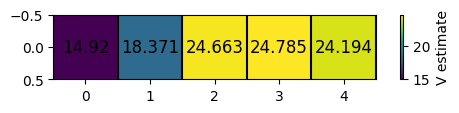

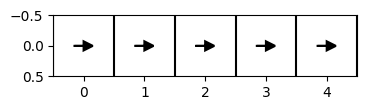

In [8]:
best_Q = np.max(Q,axis = 1)
plot_chain(best_Q.reshape(1,chain_length),pi,gradient = True,actions = False)
plot_chain(best_Q.reshape(1,chain_length),pi,gradient = False,actions = True)

In [9]:
MC_dict = {
    'episodes':episodes,
    'mean_accuracies':accuracies,
    'n_runs':n_runs,
    'n_episodes':total_episodes,
    'epsilon':epsilon,
    'gamma':gamma,
    'best R': best_R,
    'eval_iter':eval_iter
}

In [10]:
log_path = dir_name + '/MC_data.txt'
with open(log_path,"w") as text_file:
    for (key,value) in zip(MC_dict.keys(),MC_dict.values()):
        print(f"{key}: {value}",file = text_file)

# 3: SARSA solution
**SARSA** is another classic RL algorithm. In terms of theory, the solution it provides is equivalent to MC (at convergence), but achieves it by applying immediately its acquired knowledge instead of waiting the end of the episode. This usually allows SARSA to be faster than MC, but we will see that applying immediate rewards and early update of estimates may lead to wrong conclusions. The algorithm is the following:
1) Random initialization of policy $\pi$ and state-action values $Q(s,a)$ for all $(s,a)$ pairs
2) Initialization of the episode (initial state) and ensurement that all actions have probability > 0 (ensure exploration)
3) Take action $A$ from $S$ based on $\pi$
4) Observe $R$ and $S'$ (arrival state)
5) Choose $A'$ from $S'$ based on $\pi$ (commitment of the next action is done before the update)
6) Update $Q(S,A)=Q(S,A)+\alpha(R + \gamma Q(S',A') -Q(S,A))$
7) Go back to 3. until the end of episode
8) Loop from 2. until convergence


Behavior of SARSA is interesting in this problem. Being the update immediate, it prefers the reset reward (+2) rather than the long chain reward (+10), interpreted as more risky. Thus, the policy and the estimate of SARSA end up being suboptimal

In [11]:
accuracies = np.zeros(int(total_episodes / modulo))


start_time = time.time()

for n_run in range(n_runs):
    Q = np.zeros((chain_length,2))
    pi = np.ones((chain_length,2)) / 2.   # initialize actions uniformly across all choices
    alpha = 0.1
    max_steps = 25                                  # 2*chain_length**2
    t = 0
    acc = []
    episodes = []
    #print(n_run)
    while t < total_episodes:
        t += 1
        # episode loop
        # initialization
        state = 0
        step_counter = 0
        
        # epsilon greedy choice
        action_idx = np.random.choice(np.arange(0,2,1),p = pi[state,:])  # choose action 0 or 1 according to pi
       
        # loop until end of episode
        while step_counter < max_steps:
            # take such action
            if action_idx == 0:  # move right with p=0.8, reset p = 0.2
                rand = np.random.uniform(0,1)
                if rand <= 0.8:
                    new_state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10  # no reward for moving on right (10 if last state)
                else:
                    new_state = 0
                    r = 2  # reset leads reward 2
            if action_idx == 1:  # move right with p=0.2, reset p = 0.8
                rand = np.random.uniform(0,1)
                if rand <= 0.2:
                    new_state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10 # no reward for moving on right (10 if last state)
                else:
                    new_state = 0
                    r = 2  # reset leads reward 2
    
            # we have state and new state
            step_counter += 1
            # select future action based on new state
            # epsilon greedy
            new_action_idx = np.random.choice(np.arange(0,2,1),p = pi[new_state,:])  # choose action 0 or 1 according to pi
        
            # update state-action value
            Q[state,action_idx] = Q[state,action_idx]+ alpha * (r + gamma * Q[new_state,new_action_idx]-Q[state,action_idx]) 
            # update policy according to Q (epsilon greedy)
            best_action = np.argmax(Q[state,:])
            pi[state,:] = epsilon / 2.
            pi[state,best_action] += 1 - epsilon
                
            
            # update state and action
            state = new_state
            action_idx = new_action_idx
    
        if t % modulo == 0:
            pi_eval = np.argmax(pi,axis = 1)
            eval_iter = 1000
            _,_,_,avg_cum = policy_estimator(pi_eval,chain_length,eval_iter,plot_flag=False,path=None,tipo = 'SARSA')
            acc.append(avg_cum[-1])
            episodes.append(t)
    accuracies = np.array(acc) / (n_run + 1) + accuracies * (n_run)/(n_run+1)
        

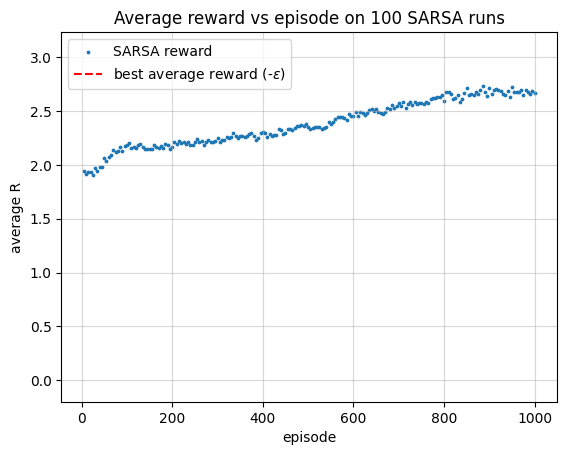

2.383 0.212


In [12]:
plt.scatter(episodes,accuracies, label = 'SARSA reward',s=3)
plt.title(f'Average reward vs episode on {n_runs} SARSA runs')
plt.xlabel('episode')
plt.ylabel('average R')
plt.ylim(-0.2,max(accuracies)+0.5)
plt.hlines(y = best_R*(1.-epsilon), xmin = episodes[0],xmax = episodes[-1],colors = 'red', linestyles = '--', label = r'best average reward (-$\epsilon$)')
plt.legend()
plt.grid(alpha = 0.5)
path = dir_name + f'/SARSA_avg_reward_{n_runs}_runs.png'
plt.savefig(path)
plt.show()


print(round(np.mean(accuracies),3),round(np.std(accuracies),3))

In [13]:
pi

array([[0.025, 0.975],
       [0.025, 0.975],
       [0.025, 0.975],
       [0.975, 0.025],
       [0.025, 0.975]])

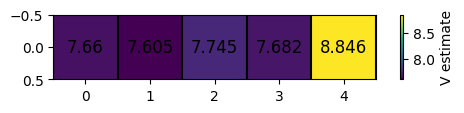

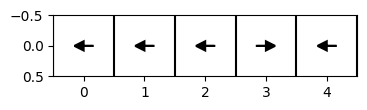

In [14]:
best_Q = np.max(Q,axis = 1)
best_pi = np.argmax(pi,axis = 1)
plot_chain(best_Q.reshape(1,chain_length),best_pi,gradient = True,actions = False)
plot_chain(best_Q.reshape(1,chain_length),best_pi,gradient = False,actions = True)

In [15]:
SARSA_dict = {
    'episodes':episodes,
    'mean_accuracies':accuracies,
    'n_runs':n_runs,
    'n_episodes':total_episodes,
    'epsilon':epsilon,
    'gamma':gamma,
    'best R': best_R,
    'eval_iter':eval_iter
}

In [16]:
log_path = dir_name + '/SARSA_data.txt'
with open(log_path,"w") as text_file:
    for (key,value) in zip(SARSA_dict.keys(),SARSA_dict.values()):
        print(f"{key}: {value}",file = text_file)

### Comparison plot

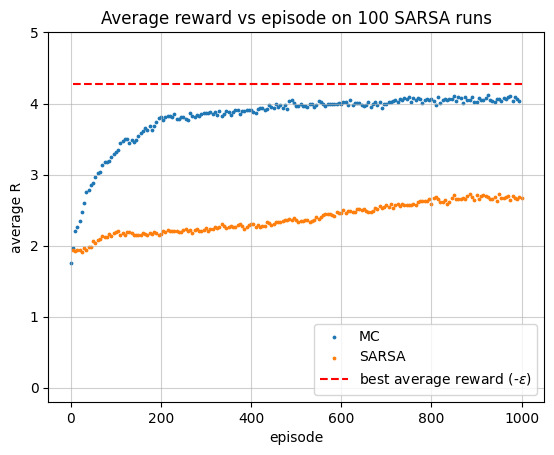

In [17]:
plt.scatter(MC_dict['episodes'],MC_dict['mean_accuracies'],label ='MC',s=3)
plt.scatter(SARSA_dict['episodes'],SARSA_dict['mean_accuracies'],label ='SARSA',s=3)
plt.title(f'Average reward vs episode on {n_runs} SARSA runs')

plt.grid(alpha = 0.6)
plt.hlines(y = best_R*(1.-epsilon), xmin = episodes[0],xmax = episodes[-1],colors = 'red', linestyles = '--', label = r'best average reward (-$\epsilon$)')
plt.xlabel('episode')
plt.ylabel('average R')
plt.ylim(-0.2,best_R+0.5)
plt.legend(loc='lower right')
path = dir_name + f'/MCSARSA_avg_reward_{n_runs}_runs.png'
plt.savefig(path)
plt.show()


Very rarely it happens that MC outclasses SARSA. Here the problem is constructed to penalize early update and limited exploration, that is one flaw of SARSA. MC, on the other hand, updates only at the end of the episode, allowing itself to find where are and how to reach the best rewards.

# 4 Posterior Sampling solution
A solution that uses Bayesian Inference is **Posterior Sampling**. It can be said that it is the equivalent of **Thompson Sampling** for multi-state problems, since Thompson is used in Bandits (that are mono-state problems). 

Let our problem be defined as a **Markov Decision Process** with unknown transition probabilities. The MDP is the tuple $M=(S,A,P,R,H)$ where:
- $S$ state space
- $A$ action space
- $P$ transition probability
- $R$ reward distribution
- $H$ hypothesis space

We must find $P=(T(s_i,a_j,s'))$ that are transition probabilities from state $s_i$ by performing action $a_j$ and landing on state $s'$. The algorithm is defined in the following way:
1) Initialize $P(\cdot|s,a)\sim Dir(\alpha_{s,a})$ as Dirichlet distributed
2) Sample the MDP from $P$
3) Compute optimal value function $V(s)$ and optimal state-action value function $Q(s,a)$ from the obtained sample of $P$
4) Determine the greedy policy $\pi(s) = argmax_aQ(s,a)$ for all states
5) Update the posterior for any visited tuple $(s,a,s')$: $\alpha_{s,a}(s')\gets \alpha_{s,a}(s')+1$
6) Repeat from 2. with the updated distribution

The algorithm is consistent, being Dirichlet conjugate to categorical, and automatically balances between exploration and exploitation thanks to parameters update


In [18]:
def value_iteration(P, R, gamma, n_states, n_actions, n_iter=50):
    V = np.zeros(n_states)
    for _ in range(n_iter):
        Q = np.zeros((n_states, n_actions))
        for s in range(n_states):
            for a in range(n_actions):
                Q[s,a] = np.sum(P[s,a,:] * (R[s,a,:] + gamma * V))
        V = np.max(Q, axis=1)
    return Q

def bayesian_chain(chain_length=5,
                   total_episodes=1000,
                   gamma=0.8,
                   max_steps=25,
                   modulo = 20):

    n_states = chain_length
    n_actions = 2
    
    # Dirichlet prior over transitions
    # alpha[s,a,s'] counts transitions
    alpha = np.ones((n_states, n_actions, n_states))
    
    episodes = []
    pis = []
    acc = []
    
    for episode in range(total_episodes):
        
        # 1) sample MDP from posterior
        P_sample = np.zeros_like(alpha)
        for s in range(n_states):
            for a in range(n_actions):
                P_sample[s,a,:] = np.random.dirichlet(alpha[s,a,:])
        
        # true reward model
        R = np.zeros((n_states,n_actions,n_states))
        for s in range(n_states):
            for a in range(n_actions):
                for s2 in range(n_states):
                    if s2 == 0 and s != 0:
                        R[s,a,s2] = 2
                    if s == chain_length-1 and s2 == chain_length-1:
                        R[s,a,s2] = 10
        
        # 2) solve sampled MDP
        Q = value_iteration(P_sample, R, gamma,
                            n_states, n_actions)
        policy = np.argmax(Q, axis=1)
        
        # 3) run episode
        state = 0
        cum_reward = 0
        
        for step in range(max_steps):
            
            action = policy[state]
            
            if action == 0:
                p_forward = 0.8
            else:
                p_forward = 0.2
            
            if np.random.rand() <= p_forward:
                new_state = min(state+1, chain_length-1)
                r = 10 if state == chain_length-1 else 0
            else:
                new_state = 0
                r = 2
            
            cum_reward += r
            
            # 4) update posterior 
            alpha[state,action,new_state] += 1
            
            state = new_state
        
        if episode % modulo == 0:
            pi_eval = policy
            eval_iter = 10000
            _,_,_,avg_cum = policy_estimator(pi_eval,chain_length,eval_iter,plot_flag=False,path=None,tipo = 'Bayesian')
            acc.append(avg_cum[-1])
            episodes.append(episode)
            pis.append(policy)
    
    return episodes, acc, pis

In [19]:
episodes,accuracies,pis = bayesian_chain(chain_length=chain_length,total_episodes=total_episodes,gamma=gamma,max_steps=max_steps,modulo = modulo)

Bayesian_dict = {
    'episodes':episodes,
    'mean_accuracies':accuracies,
    'n_runs':n_runs,
    'n_episodes':total_episodes,
    'epsilon':epsilon,
    'gamma':gamma,
    'best R': best_R,
    'eval_iter':eval_iter
}

log_path = dir_name + '/BayesianInference_data.txt'
with open(log_path,"w") as text_file:
    for (key,value) in zip(Bayesian_dict.keys(),Bayesian_dict.values()):
        print(f"{key}: {value}",file = text_file)

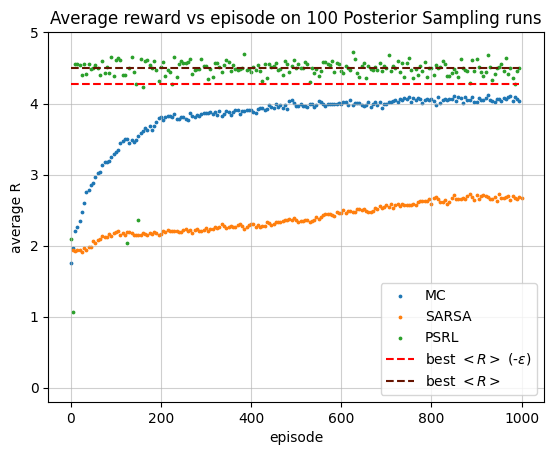

4.446 0.382


In [20]:
plt.scatter(MC_dict['episodes'],MC_dict['mean_accuracies'],label ='MC',s=3)
plt.scatter(SARSA_dict['episodes'],SARSA_dict['mean_accuracies'],label ='SARSA',s=3)
plt.scatter(Bayesian_dict['episodes'],Bayesian_dict['mean_accuracies'],label ='PSRL',s=3)
plt.title(f'Average reward vs episode on {n_runs} Posterior Sampling runs')
plt.grid(alpha = 0.6)
plt.hlines(y = best_R*(1.-epsilon), xmin = episodes[0],xmax = episodes[-1],colors = 'red', linestyles = '--', label = r'best $<R>$ (-$\epsilon$)')
plt.hlines(y = best_R, xmin = episodes[0],xmax = episodes[-1],colors = '#661400', linestyles = '--', label = r'best $<R>$')
plt.xlabel('episode')
plt.ylabel('average R')
plt.ylim(-0.2,best_R+0.5)
plt.legend(loc='lower right')
path = dir_name + f'/MCSARSABayesianInf_avg_reward_{n_runs}_runs.png'
plt.savefig(path)
plt.show()


print(round(np.mean(accuracies),3),round(np.std(accuracies),3))

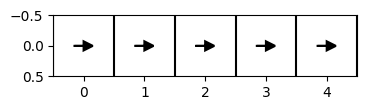

In [21]:

plot_chain(V.reshape(1,chain_length),pis[-1],gradient = False,actions = True)

Results obtained with Posterior Sampling are much better than ones of MC and SARSA. The problem is built to favour deep exploration and penalize naive exploration and early updates. Posterior Sampling needs just one of its iteration to land the right-most state to determine the best strategy, and that occurs in episodes that are orders of magnitude earlier than when MC does.